# Knapsack: A Constrained Binary Optimisation Problem

Feature selection from the previous notebook was a *soft* binary problem — every $x \in \{0,1\}^n$ was a valid (though perhaps bad) solution.  
The **0/1 Knapsack problem** adds a hard *capacity constraint*:

$$\text{maximise} \quad \sum_{i=1}^{n} v_i x_i \qquad \text{subject to} \quad \sum_{i=1}^{n} w_i x_i \leq W$$

- $x_i \in \{0,1\}$ — include item $i$ or not  
- $v_i$ — value of item $i$  
- $w_i$ — weight of item $i$  
- $W$ — knapsack capacity  

This is NP-hard in general, but solvable exactly by **dynamic programming** (DP) for moderate $n$ and $W$.

We use the DP solution to set $f^*$ precisely, which lets us measure REL, MNE, and FEO exactly as in previous sessions.

This notebook covers:
1. The objective function and the penalty approach to constraint handling
2. The known optimal (DP) and how it defines $f^*$
3. Random Search (Shoot, $h_{\max}=0$) baseline
4. FSA
5. GO
6. Algorithm comparison (REL / MNE / FEO)
7. Penalty coefficient sensitivity

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_knapsack import Knapsack
from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, Crossover
from heur_sg import ShootAndGo
from heur_aux import BitFlipMutation

## 1. The Objective Function and Penalty Approach

We transform the maximisation problem with a constraint into unconstrained minimisation using a **linear penalty**:

$$\mathrm{f}(x) = -\sum_{i} v_i x_i \;+\; \lambda \cdot \max\!\left(0,\; \sum_{i} w_i x_i - W\right)$$

where $\lambda$ (the penalty coefficient) is the cost per unit of excess weight.

**Choosing $\lambda$:** for the constrained optimum to equal the unconstrained one, we need $\lambda$ large enough that no infeasible solution can be optimal.  
A sufficient condition is $\lambda > \max_i (v_i / w_i)$.  
With $v_i, w_i \in [1, 20]$ the worst-case value density is $20/1 = 20$, so $\lambda = 100$ is safely sufficient.

**Instance:** $n = 50$ items, weights and values drawn uniformly from $[1, 20]$, capacity $= 40\%$ of total weight.  
The optimal value is computed at construction time by DP.

**Success criterion:** finding the *exact* optimum of a 50-item knapsack is very demanding for a metaheuristic with a fixed evaluation budget. We therefore define success as reaching **95 % of the DP optimal value** (`target_pct=0.95`), which is a realistic engineering target and produces a meaningful spread of REL values across algorithms.

In [3]:
ks = Knapsack(n=50, capacity_ratio=0.4, seed=42, penalty=100.0, target_pct=0.95)

print(f'Number of items  : {ks.n_items}')
print(f'Total weight     : {np.sum(ks.weights)}')
print(f'Capacity         : {ks.capacity}  ({ks.capacity / np.sum(ks.weights):.0%} of total weight)')
print(f'Total value      : {np.sum(ks.values)}  (if all items selected)')
print(f'Optimal value    : {ks.optimal_value}  (DP solution)')
print(f'fstar            : {ks.fstar:.1f}  (= -optimal_value × 0.95, success threshold)')

Number of items  : 50
Total weight     : 567
Capacity         : 226  (40% of total weight)
Total value      : 534  (if all items selected)
Optimal value    : 384  (DP solution)
fstar            : -364.8  (= -optimal_value × 0.95, success threshold)


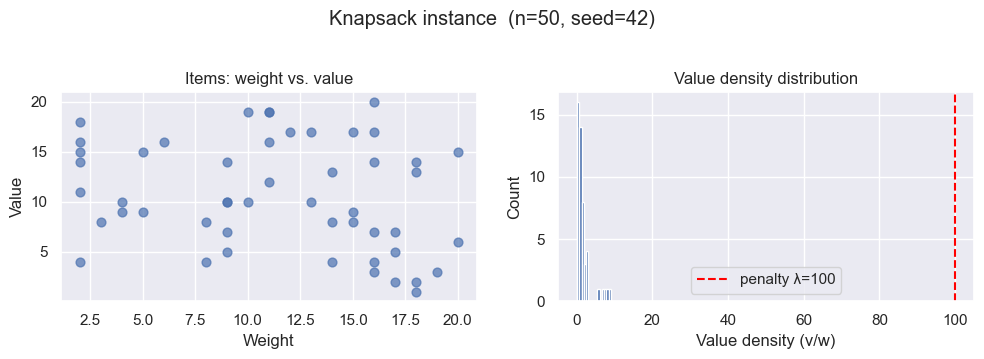

In [4]:
# Show the weight–value distribution of items
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].scatter(ks.weights, ks.values, alpha=0.7, s=40)
axes[0].set_xlabel('Weight'); axes[0].set_ylabel('Value')
axes[0].set_title('Items: weight vs. value')

axes[1].hist(ks.values / ks.weights, bins=15, edgecolor='white')
axes[1].axvline(ks.penalty, color='red', linestyle='--', label=f'penalty λ={ks.penalty:.0f}')
axes[1].set_xlabel('Value density (v/w)'); axes[1].set_ylabel('Count')
axes[1].set_title('Value density distribution')
axes[1].legend()

plt.suptitle('Knapsack instance  (n=50, seed=42)', y=1.02)
plt.tight_layout()

In [5]:
# Sanity-check: a random solution
rng = np.random.default_rng(7)
x_rand = ks.generate_point(rng)
info = ks.solution_info(x_rand)

print(f'Random solution f(x) = {ks.evaluate(x_rand):.1f}')
for k, v in info.items():
    print(f'  {k:12s}: {v}')

Random solution f(x) = 7407.0
  value       : 293
  weight      : 303
  capacity    : 226
  feasible    : False
  n_items     : 27


## 2. Random Search Baseline

`ShootAndGo(hmax=0)` is pure random shooting — no local search.  
It sets the lower bar: if FSA or GO cannot beat random search, something is wrong.

We use **500 runs**, `maxeval = 2000`.

In [6]:
NUM_RUNS = 500
MAXEVAL  = 2000

def stats(df):
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    return pd.Series({'REL': rel, 'MNE': mne, 'FEO': feo})

def run_algo(algo_fn, label, num_runs=NUM_RUNS):
    records = []
    for seed in tqdm(range(num_runs), desc=label, leave=False):
        res = algo_fn(seed)
        records.append({
            'label': label, 'seed': seed,
            'best_y': res['best_y'], 'neval': res['neval'],
            'success': res['success'], 'best_x': res['best_x'],
        })
    return pd.DataFrame(records)

In [7]:
def rs_run(seed):
    return ShootAndGo(ks, maxeval=MAXEVAL, hmax=0, seed=seed).search()

df_rs = run_algo(rs_run, 'Random Search')
print(stats(df_rs).to_string())

Random Search:   0%|          | 0/500 [00:00<?, ?it/s]

REL    0.0
MNE    NaN
FEO    NaN


## 3. Shoot & Go (Local Search)

Unrestricted `ShootAndGo(hmax=inf)` performs steepest descent from each random start.  
The neighbourhood is the Hamming-1 ball — all $n$ single bit-flips.  
Local search on this neighbourhood is equivalent to a greedy add/remove of one item at a time.

In [8]:
def sg_run(seed):
    return ShootAndGo(ks, maxeval=MAXEVAL, hmax=np.inf, seed=seed).search()

df_sg = run_algo(sg_run, 'Shoot & Go')
print(stats(df_sg).to_string())

Shoot & Go:   0%|          | 0/500 [00:00<?, ?it/s]

REL    0.0
MNE    NaN
FEO    NaN


## 4. FSA with BitFlipMutation

**Parameters:**
- `T0 = 20` — at step 0, accept a solution $\Delta f = 20$ worse with probability $\approx 50\%$
- `n0 = 200`, `alpha = 2` — fast cooling, temperature effectively near 0 after ~600 steps
- `BitFlipMutation()` — default $p = 1/50$, ≈ one bit flip per step

In [9]:
def fsa_run(seed):
    mut = BitFlipMutation()
    return FastSimulatedAnnealing(
        ks, maxeval=MAXEVAL, T0=20, n0=200, alpha=2,
        mutation=mut, seed=seed
    ).search()

df_fsa = run_algo(fsa_run, 'FSA')
print(stats(df_fsa).to_string())

FSA:   0%|          | 0/500 [00:00<?, ?it/s]

REL       0.428000
MNE    1404.242991
FEO    3280.941567


## 5. GO with BitFlipMutation

**Parameters:** $N=20$, $M=60$, $T_{\text{sel1}}=0.5$, $T_{\text{sel2}}=0.5$, `BitFlipMutation()`.

In [10]:
def go_run(seed):
    mut = BitFlipMutation()
    co  = Crossover()
    return GeneticOptimization(
        ks, maxeval=MAXEVAL, N=20, M=60,
        Tsel1=0.5, Tsel2=0.5,
        mutation=mut, crossover=co, seed=seed
    ).search()

df_go = run_algo(go_run, 'GO')
print(stats(df_go).to_string())

GO:   0%|          | 0/500 [00:00<?, ?it/s]

REL      0.998000
MNE    769.480962
FEO    771.023008


## 6. Algorithm Comparison

In [11]:
summary = pd.DataFrame([
    {'Algorithm': 'Random Search', **stats(df_rs)},
    {'Algorithm': 'Shoot & Go',    **stats(df_sg)},
    {'Algorithm': 'FSA',           **stats(df_fsa)},
    {'Algorithm': 'GO',            **stats(df_go)},
]).set_index('Algorithm')

print(summary.to_string())

                 REL          MNE          FEO
Algorithm                                     
Random Search  0.000          NaN          NaN
Shoot & Go     0.000          NaN          NaN
FSA            0.428  1404.242991  3280.941567
GO             0.998   769.480962   771.023008


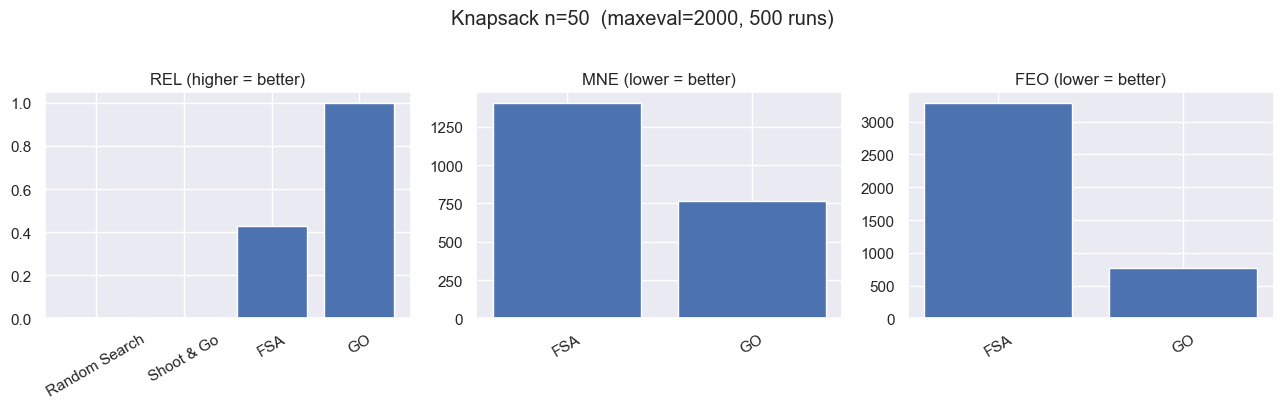

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric, ylabel in zip(axes,
                               ['REL', 'MNE', 'FEO'],
                               ['REL (higher = better)', 'MNE (lower = better)', 'FEO (lower = better)']):
    vals = summary[metric].dropna()
    ax.bar(vals.index, vals.values)
    ax.set_title(ylabel)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Knapsack n=50  (maxeval={MAXEVAL}, {NUM_RUNS} runs)', y=1.02)
plt.tight_layout()

In [13]:
# Inspect the best solution found across all algorithms
all_results = pd.concat([df_rs, df_sg, df_fsa, df_go], ignore_index=True)
best_overall = all_results.loc[all_results['best_y'].idxmin()]
info = ks.solution_info(best_overall['best_x'])

print(f'Best solution found by: {best_overall["label"]}')
print(f'  f(x)        = {best_overall["best_y"]:.1f}')
print(f'  value       = {info["value"]}  (DP optimal = {ks.optimal_value})')
print(f'  weight      = {info["weight"]} / {info["capacity"]} (capacity)')
print(f'  feasible    = {info["feasible"]}')
print(f'  items used  = {info["n_items"]} / {ks.n_items}')

Best solution found by: GO
  f(x)        = -380.0
  value       = 380  (DP optimal = 384)
  weight      = 225 / 226 (capacity)
  feasible    = True
  items used  = 28 / 50


## 7. Penalty Coefficient Sensitivity

The penalty $\lambda$ controls how strongly the constraint is enforced.

- **$\lambda$ too small:** infeasible solutions can *outscore* feasible ones — a solution that exceeds capacity by a few units still looks attractive to the algorithm. REL appears high, but pct_feasible is low: the algorithm is cheating.
- **$\lambda$ sufficient:** once $\lambda > \max_i(v_i / w_i) = 20$ for our instance, no infeasible solution can be optimal and all runs end feasible. REL stabilises.
- **$\lambda$ very large:** the constraint is treated like a hard wall; the algorithm avoids the capacity boundary and focuses entirely on feasible space. In practice there is little further change in REL beyond the sufficient threshold.

We sweep $\lambda \in \{1, 5, 20, 50, 100, 500\}$ using FSA and observe REL, average solution value, and the fraction of runs ending in a feasible solution.

In [14]:
PENALTY_VALUES = [1, 5, 20, 50, 100, 500]
N_RUNS_SWEEP   = 200

sweep_records = []
for lam in PENALTY_VALUES:
    ks_p = Knapsack(n=50, capacity_ratio=0.4, seed=42, penalty=lam, target_pct=0.95)
    for seed in tqdm(range(N_RUNS_SWEEP), desc=f'λ={lam}', leave=False):
        mut = BitFlipMutation()
        res = FastSimulatedAnnealing(
            ks_p, maxeval=MAXEVAL, T0=20, n0=200, alpha=2,
            mutation=mut, seed=seed
        ).search()
        info = ks_p.solution_info(res['best_x'])
        sweep_records.append({
            'penalty': lam,
            'success': res['success'],
            'neval':   res['neval'],
            'value':   info['value'],
            'feasible': info['feasible'],
        })

df_sweep = pd.DataFrame(sweep_records)

sweep_agg = df_sweep.groupby('penalty').agg(
    REL         =('success',  'mean'),
    avg_value   =('value',    'mean'),
    pct_feasible=('feasible', 'mean'),
).reset_index()
print(sweep_agg.to_string(index=False))

λ=1:   0%|          | 0/200 [00:00<?, ?it/s]

λ=5:   0%|          | 0/200 [00:00<?, ?it/s]

λ=20:   0%|          | 0/200 [00:00<?, ?it/s]

λ=50:   0%|          | 0/200 [00:00<?, ?it/s]

λ=100:   0%|          | 0/200 [00:00<?, ?it/s]

λ=500:   0%|          | 0/200 [00:00<?, ?it/s]

 penalty   REL  avg_value  pct_feasible
       1 1.000    378.760         0.160
       5 0.575    364.325         0.915
      20 0.455    362.030         1.000
      50 0.480    362.340         1.000
     100 0.435    361.525         1.000
     500 0.490    362.715         1.000


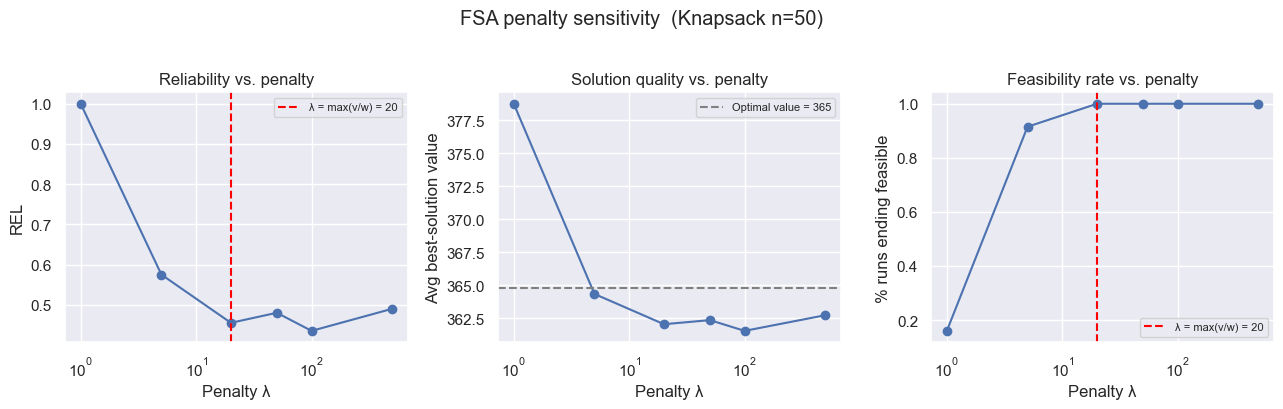

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].semilogx(sweep_agg['penalty'], sweep_agg['REL'], marker='o')
axes[0].axvline(20, color='red', linestyle='--', label='λ = max(v/w) = 20')
axes[0].set_xlabel('Penalty λ'); axes[0].set_ylabel('REL')
axes[0].set_title('Reliability vs. penalty')
axes[0].legend(fontsize=8)

axes[1].semilogx(sweep_agg['penalty'], sweep_agg['avg_value'], marker='o')
axes[1].axhline(-ks.fstar, color='gray', linestyle='--', label=f'Optimal value = {-ks.fstar:.0f}')
axes[1].set_xlabel('Penalty λ'); axes[1].set_ylabel('Avg best-solution value')
axes[1].set_title('Solution quality vs. penalty')
axes[1].legend(fontsize=8)

axes[2].semilogx(sweep_agg['penalty'], sweep_agg['pct_feasible'], marker='o')
axes[2].axvline(20, color='red', linestyle='--', label='λ = max(v/w) = 20')
axes[2].set_xlabel('Penalty λ'); axes[2].set_ylabel('% runs ending feasible')
axes[2].set_title('Feasibility rate vs. penalty')
axes[2].legend(fontsize=8)

plt.suptitle('FSA penalty sensitivity  (Knapsack n=50)', y=1.02)
plt.tight_layout()

## Summary

### Domain generalisation

The Knapsack problem confirms the pattern from feature selection: changing to the binary domain requires only:
- `a = 0`, `b = 1` (integer), `generate_point` returning binary vectors
- `BitFlipMutation` replacing `CauchyMutation`
- `get_neighborhood` returning all Hamming-1 neighbours

All heuristics (RS, SG, FSA, GO) work unchanged.

### Algorithm performance (n=50, target ≥ 95 % of optimal, maxeval=2 000)

| Algorithm | REL | FEO |
|-----------|-----|-----|
| Random Search | 0 % | — |
| Shoot & Go | 0 % | — |
| FSA | 43 % | ≈ 3 280 |
| GO | **99.8 %** | **≈ 771** |

Random search and steepest-descent local search both fail: the search space ($2^{50} \approx 10^{15}$ solutions) is far too large for random shooting, and the Hamming-1 neighbourhood is dense with local optima that are well below the 95 % threshold.

FSA escapes local optima through temperature-controlled acceptance and reaches the target in 43 % of runs. GO dominates by a large margin — crossover lets individuals share item selections, effectively combining good partial solutions from different regions of the space. At 99.8 % REL and a mean of only 769 evaluations to success, GO is well-matched to binary combinatorial problems like Knapsack.

### The penalty mechanism

The sweep confirms the theoretical threshold $\lambda > \max(v_i/w_i) = 20$:
- **$\lambda = 1$:** REL = 100 %, but only 16 % of solutions are feasible — the algorithm is finding high-value infeasible solutions that satisfy $f(x) \leq f^*$ because the penalty is negligible.
- **$\lambda = 5$:** transition — 91 % feasible, but some infeasible "successes" remain.
- **$\lambda \geq 20$:** 100 % feasible in all runs; REL stabilises at 44–49 % (noise around FSA's true REL). Higher penalties do not further harm performance.

The practical lesson: once $\lambda$ exceeds the maximum value density, the exact value of $\lambda$ matters little. The danger zone is $\lambda < \max(v/w)$, where misleadingly high REL numbers hide infeasible solutions.

Penalty selection will be revisited systematically in **Session 10 (Constraint Handling)**.

### Assignments
- GO already achieves 99.8 % REL with `maxeval=2 000`. Reduce `maxeval` to 500, 200, 100. At what budget does GO's advantage over FSA begin to shrink?
- Try `n = 100` items. How do REL values change? Which algorithm degrades most gracefully?
- Implement a **greedy repair** operator: given an infeasible $x$, remove the item with the worst value-density ratio until the constraint is satisfied. Use it instead of the penalty and compare REL/FEO.
- The DP computes the optimal in $O(n \cdot W)$ time. For $n = 1000$ and $W = 10^6$, the DP becomes impractical — why? What algorithm would you use then?
- Modify `generate_point` to produce only *feasible* starting solutions (greedy fill by value density). Does this improve REL for FSA? When might it hurt?

# Proposed topics for the rest of the semester — happy to hear any feedback

| Session | Topic | New domain / technique |
|---------|-------|------------------------|
| 07 | Differential Evolution | A different population-based algorithm with reputable performance |
| 08 | Working without known $f^*$ | Convergence analysis, anytime performance |
| 09 | Hybrid / memetic methods | Local search embedded in population search |
| 10 | Constraint handling (cont.) | Penalty, repair, death penalty |
| 11 | No Free Lunch + algorithm comparison | Theoretical grounding, systematic evaluation |
| 12 | Third-party frameworks (DEAP, Optuna, COCO) | External ecosystem context |